In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, linear_model, model_selection
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Fitterizzi

## Load and clean

In [2]:
fitterizzi = pd.read_excel('./Dati chimici_fisici.xlsx', header=1, sheet_name="Fitterizzi")

In [3]:
print(fitterizzi.columns)
print(len(fitterizzi.columns))

Index(['Data', 'Ora Solare', 'Data + Ora Solare', 'fDOM Orario(QSU)',
       'Turbidity [FNU]', 'Temp YSI [°C]', 'fDOMT', 'fDOMcorr',
       'fDOMcorrSoglia', 'fDOMcorr>soglia', 'DOC formula',
       'Portate Fitterizzi [mc/s]', 'Livel Idro Fit [m]', 'Pioggia Fit [mm]',
       'Temp Fit [C°]', 'Umidità Fit [%]', 'Pres Atm Fit [hPa]',
       'Rad Solare Fit  [W/mq]', 'Vel Vento Fit', 'DDOC', 'DQ', 'DQ+1', 'DQ+2',
       'DQ+3', 'DQ+4', 'Q+1', 'Q+2', 'Q+3', 'Q+4', 'Pacc 2', 'Pacc 3',
       'Pacc 4', 'Pacc 5', 'Pacc 6', 'Pacc 7', 'Pacc 8', 'Pacc 9', 'Pacc 10',
       'Pacc 11', 'Pacc 12', 'DOC depurato', 'lm 17 par all',
       'DOC dep + lm 17 par all', 'lm 5 par all', 'lm 1 par all',
       'lm 17 par 2021', 'lm 6 par 2021', 'lm 1 par 2021',
       'lm 17 par inv 2021', 'lm 4 par inv 2021', 'lm 1 par inv 2021'],
      dtype='object')
51


In [4]:
valid_columns = fitterizzi.columns[:20]
valid_columns

Index(['Data', 'Ora Solare', 'Data + Ora Solare', 'fDOM Orario(QSU)',
       'Turbidity [FNU]', 'Temp YSI [°C]', 'fDOMT', 'fDOMcorr',
       'fDOMcorrSoglia', 'fDOMcorr>soglia', 'DOC formula',
       'Portate Fitterizzi [mc/s]', 'Livel Idro Fit [m]', 'Pioggia Fit [mm]',
       'Temp Fit [C°]', 'Umidità Fit [%]', 'Pres Atm Fit [hPa]',
       'Rad Solare Fit  [W/mq]', 'Vel Vento Fit', 'DDOC'],
      dtype='object')

In [5]:
reduced_fitterizzi = fitterizzi[valid_columns]
reduced_fitterizzi.head()

,Data,Ora Solare,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,fDOMcorrSoglia,fDOMcorr>soglia,DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit,DDOC
0,2019-05-22,18:00:00,2019-05-22 18:00:00,13.260000,13.571667,16.498333,12.221010,12.902787,200.970200,12.902787,1.496750,0.056543,0.38,0.0,19.8,-,994.3,202,7.1,0.000000
1,2019-05-22,19:00:00,2019-05-22 19:00:00,13.933333,12.643333,15.787667,12.758022,13.419831,209.801163,13.419831,1.524671,0.056543,0.38,0.0,18,-,994.6,0,8.6,0.027920
2,2019-05-22,20:00:00,2019-05-22 20:00:00,14.605000,12.095000,15.097667,13.289072,13.947803,218.534092,13.947803,1.553181,0.056543,0.38,0.0,17.2,-,994.9,0,6.2,0.028510
3,2019-05-22,21:00:00,2019-05-22 21:00:00,14.641667,12.635000,14.543667,13.255615,13.942772,217.983912,13.942772,1.552910,0.039208,0.36,0.0,15.3,-,995.4,0,2.5,-0.000272
4,2019-05-22,22:00:00,2019-05-22 22:00:00,14.815000,13.243333,13.990333,13.345685,14.071710,219.465069,14.071710,1.559872,0.047201,0.37,0.0,11.5,-,995.6,0,2.8,0.006963


In [6]:
reduced_fitterizzi.describe()

,Data,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,fDOMcorrSoglia,fDOMcorr>soglia,DOC formula,Portate Fitterizzi [mc/s],Pioggia Fit [mm],DDOC
count,11567,11567,11567.000000,11567.000000,11567.000000,11567.000000,1.156700e+04,11567.000000,11567.000000,11567.000000,11567.000000,11567.000000,11567.000000
mean,2020-10-10 05:19:49.210685696,2020-10-10 16:50:05.550272256,17.420886,42.961755,16.633281,16.120891,4.222897e+02,265.102351,20.714195,1.918567,0.113600,0.096654,0.000051
min,2019-05-22 00:00:00,2019-05-22 18:00:00,-3.843333,0.951667,6.020333,-3.534083,-4.400313e+05,-58.116753,-3.650414,0.602878,0.002397,0.000000,-24.099355
25%,2019-09-20 00:00:00,2019-09-20 05:30:00,13.033333,4.369167,13.150667,11.683323,1.280969e+01,192.128116,12.821047,1.492337,0.017754,0.000000,-0.017073
50%,2021-03-17 00:00:00,2021-03-17 18:00:00,17.645000,7.555000,16.812000,16.706802,1.785521e+01,274.737460,17.857949,1.764329,0.033998,0.000000,-0.001559
75%,2021-07-16 00:00:00,2021-07-16 05:30:00,21.256667,18.619167,20.179667,19.809180,2.145031e+01,325.754968,21.452308,1.958425,0.097226,0.000000,0.012891
max,2021-11-26 00:00:00,2021-11-26 00:00:00,48.988333,4599.815000,26.725500,45.838610,2.235576e+06,753.799744,548.228198,30.404323,6.795935,32.600000,28.722872
std,NaN,NaN,6.218767,200.417240,4.520188,5.722989,2.934691e+04,94.112528,21.974083,1.186600,0.284342,0.679577,0.778911


In [7]:
reduced_fitterizzi.isna().sum()

Data                         2
Ora Solare                   2
Data + Ora Solare            2
fDOM Orario(QSU)             2
Turbidity [FNU]              2
Temp YSI [°C]                2
fDOMT                        2
fDOMcorr                     2
fDOMcorrSoglia               2
fDOMcorr>soglia              2
DOC formula                  2
Portate Fitterizzi [mc/s]    2
Livel Idro Fit [m]           2
Pioggia Fit [mm]             2
Temp Fit [C°]                2
Umidità Fit [%]              2
Pres Atm Fit [hPa]           2
Rad Solare Fit  [W/mq]       2
Vel Vento Fit                2
DDOC                         2
dtype: int64

In [8]:
reduced_fitterizzi = reduced_fitterizzi.dropna()

In [9]:
reduced_fitterizzi.dtypes

Data                         datetime64[ns]
Ora Solare                           object
Data + Ora Solare            datetime64[ns]
fDOM Orario(QSU)                    float64
Turbidity [FNU]                     float64
Temp YSI [°C]                       float64
fDOMT                               float64
fDOMcorr                            float64
fDOMcorrSoglia                      float64
fDOMcorr>soglia                     float64
DOC formula                         float64
Portate Fitterizzi [mc/s]           float64
Livel Idro Fit [m]                   object
Pioggia Fit [mm]                    float64
Temp Fit [C°]                        object
Umidità Fit [%]                      object
Pres Atm Fit [hPa]                   object
Rad Solare Fit  [W/mq]               object
Vel Vento Fit                        object
DDOC                                float64
dtype: object

In [10]:
reduced_fitterizzi = reduced_fitterizzi[ 
    (reduced_fitterizzi['Livel Idro Fit [m]'] != '-') & 
    (reduced_fitterizzi['Temp Fit [C°]'] != '-') &
    (reduced_fitterizzi['Umidità Fit [%]'] != '-') &
    (reduced_fitterizzi['Pres Atm Fit [hPa]'] != '-') &
    (reduced_fitterizzi['Rad Solare Fit  [W/mq]'] != '-') &
    (reduced_fitterizzi['Vel Vento Fit'] != '-')
]

reduced_fitterizzi = reduced_fitterizzi.astype({
    'Livel Idro Fit [m]': 'float', 
    'Temp Fit [C°]': 'float', 
    'Umidità Fit [%]': 'float', 
    'Pres Atm Fit [hPa]': 'float', 
    'Rad Solare Fit  [W/mq]': 'float', 
    'Vel Vento Fit': 'float'
})

In [11]:
reduced_fitterizzi

,Data,Ora Solare,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,fDOMcorrSoglia,fDOMcorr>soglia,DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit,DDOC
3150,2019-10-01,00:00:00,2019-10-01 00:00:00,22.650000,8.121667,17.904000,21.149249,21.847600,347.791934,21.847600,1.979770,0.017660,0.32,0.0,14.7,89.0,993.50,0.0,1.7,-0.008393
3151,2019-10-01,01:00:00,2019-10-01 01:00:00,21.910000,10.923333,17.550667,20.391006,21.301708,335.322891,21.301708,1.950292,0.014244,0.31,0.0,13.4,92.0,993.70,0.0,1.1,-0.029478
3152,2019-10-01,02:00:00,2019-10-01 02:00:00,21.876667,12.491667,17.192833,20.292405,21.332108,333.701429,21.332108,1.951934,0.017660,0.32,0.0,13.0,94.0,993.50,0.0,1.7,0.001642
3153,2019-10-01,03:00:00,2019-10-01 03:00:00,22.271667,10.150000,16.869000,20.596930,21.450373,338.709243,21.450373,1.958320,0.017660,0.32,0.0,13.1,96.0,993.43,0.0,1.6,0.006386
3154,2019-10-01,04:00:00,2019-10-01 04:00:00,22.460000,10.101667,16.574333,20.714652,21.568803,340.645142,21.568803,1.964715,0.017660,0.32,0.0,12.2,97.0,993.33,0.0,1.6,0.006395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563,2021-11-25,20:00:00,2021-11-25 20:00:00,20.085000,2.061667,13.067500,17.943850,18.092439,295.080276,18.092439,1.776992,0.060111,0.26,0.0,11.2,97.0,986.80,0.0,1.2,0.008391
11564,2021-11-25,21:00:00,2021-11-25 21:00:00,20.556667,3.593333,13.057333,18.363567,18.629419,301.982374,18.629419,1.805989,0.060111,0.26,1.6,11.6,98.0,985.80,0.0,0.9,0.028997
11565,2021-11-25,22:00:00,2021-11-25 22:00:00,22.606667,11.055000,13.061167,20.195553,21.108640,332.108739,21.108640,1.939867,0.071638,0.27,1.0,12.0,99.0,984.70,0.0,1.6,0.133878
11566,2021-11-25,23:00:00,2021-11-25 23:00:00,24.181667,54.725000,13.078333,21.605885,26.892992,355.301148,26.892992,2.252222,0.084833,0.28,4.8,12.0,99.0,984.50,0.0,1.4,0.312355


## Data visualization

In [17]:
# Normalize data
scaler = StandardScaler()
drop_columns = ['Data', 'Ora Solare', 'Data + Ora Solare']
normalized_reduced_fitterizzi = reduced_fitterizzi.drop(drop_columns, axis=1)
normalized_reduced_fitterizzi = pd.DataFrame(scaler.fit_transform(normalized_reduced_fitterizzi))
columns = [attr for attr in reduced_fitterizzi.columns if attr not in drop_columns]
normalized_reduced_fitterizzi.columns = columns
normalized_reduced_fitterizzi.head()

,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,fDOMcorrSoglia,fDOMcorr>soglia,DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit,DDOC
0,0.830166,-0.173671,0.550004,0.906075,-0.009615,0.906075,0.063741,0.063741,-0.379288,0.381922,-0.169771,-0.322187,0.925925,-0.349491,-0.680186,-0.513687,-0.007926
1,0.722851,-0.160324,0.470452,0.784886,-0.009636,0.784886,0.040571,0.040571,-0.390217,0.271734,-0.169771,-0.480815,1.059487,-0.312804,-0.680186,-0.736070,-0.032172
2,0.718017,-0.152852,0.389887,0.769127,-0.009635,0.769127,0.041862,0.041862,-0.379288,0.381922,-0.169771,-0.529624,1.148528,-0.349491,-0.680186,-0.513687,0.003613
3,0.775300,-0.164008,0.316976,0.817799,-0.009630,0.817799,0.046881,0.046881,-0.379288,0.381922,-0.169771,-0.517422,1.237570,-0.362331,-0.680186,-0.550751,0.009070
4,0.802612,-0.164238,0.250633,0.836614,-0.009626,0.836614,0.051908,0.051908,-0.379288,0.381922,-0.169771,-0.627242,1.282090,-0.380675,-0.680186,-0.550751,0.009080


In [18]:
len(valid_columns[3:])//2

8

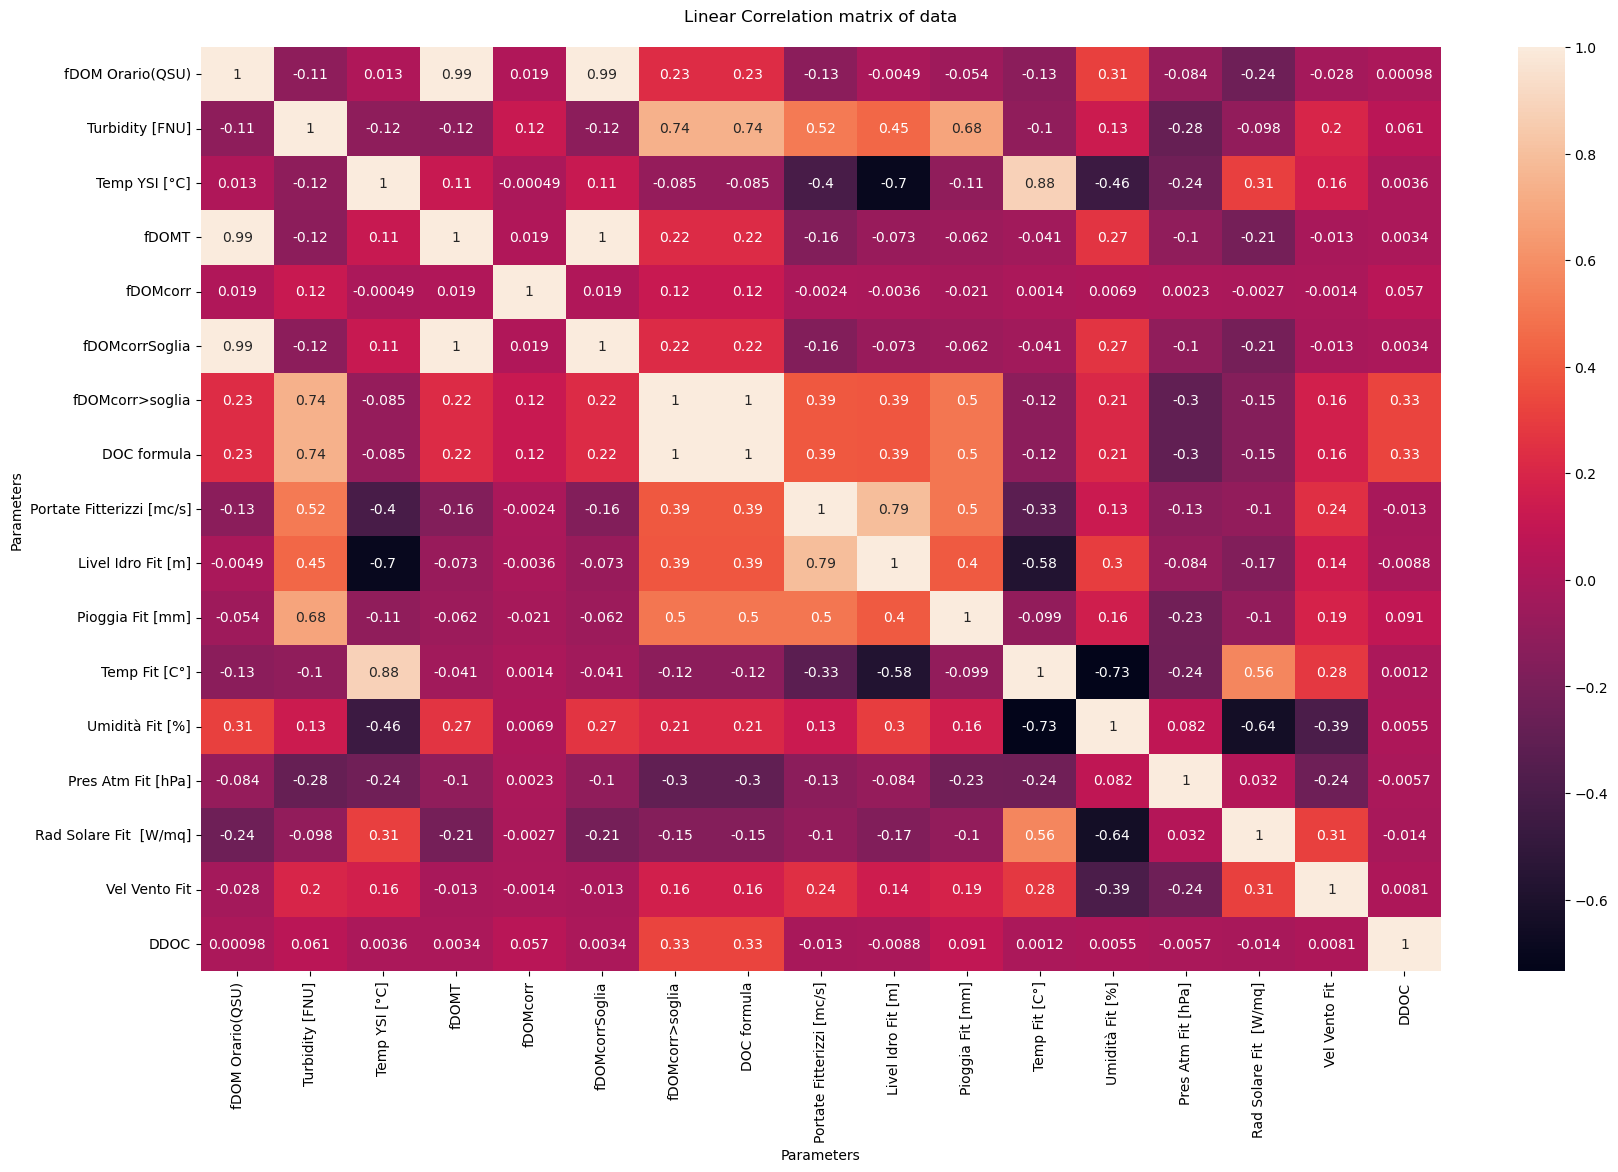

In [20]:
plt.figure(figsize = (20,12))
hm = sns.heatmap(reduced_fitterizzi.corr(numeric_only=True), annot=True)
hm.set(xlabel='Parameters', ylabel='Parameters', title = "Linear Correlation matrix of data\n")
plt.show()

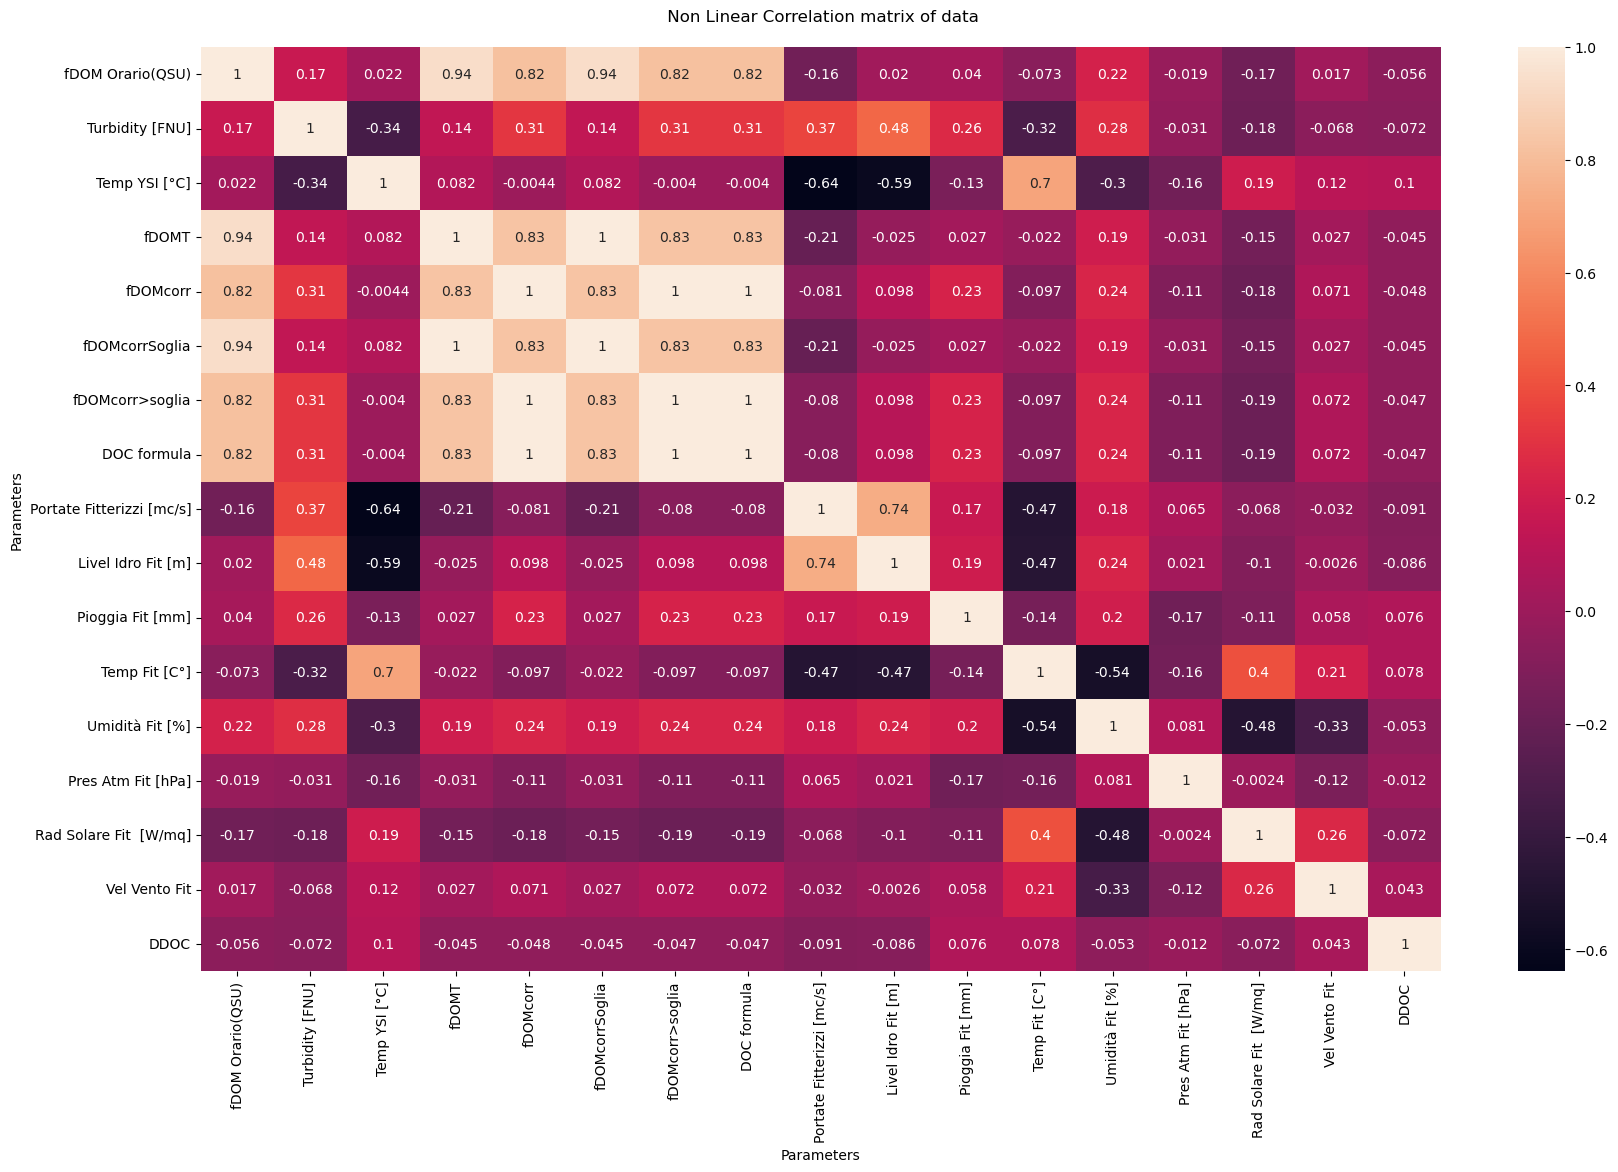

In [21]:
plt.figure(figsize = (20,12))
hm = sns.heatmap(reduced_fitterizzi.corr(numeric_only=True, method='kendall'), annot=True)
hm.set(xlabel='Parameters', ylabel='Parameters', title = " Non Linear Correlation matrix of data\n")
plt.show()

<Axes: xlabel='Data + Ora Solare'>

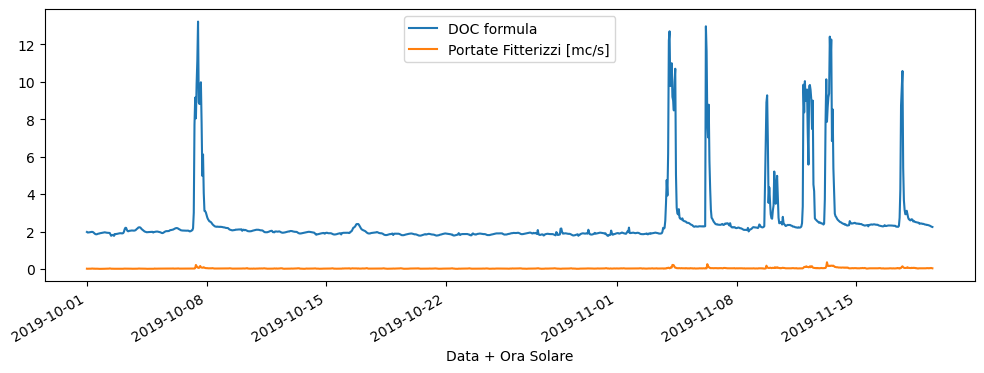

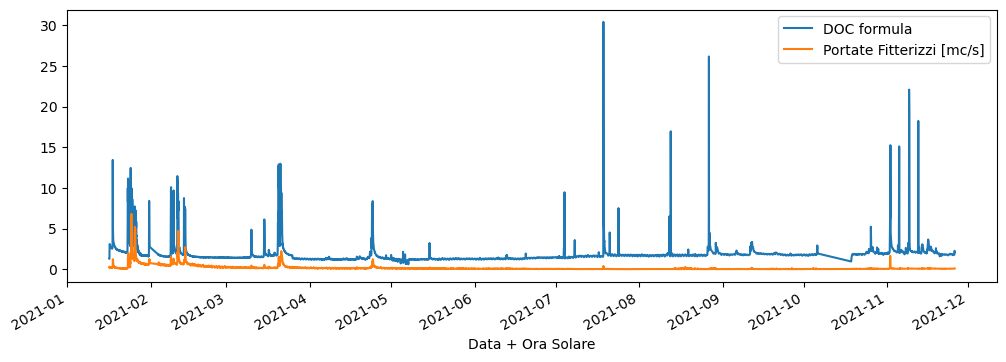

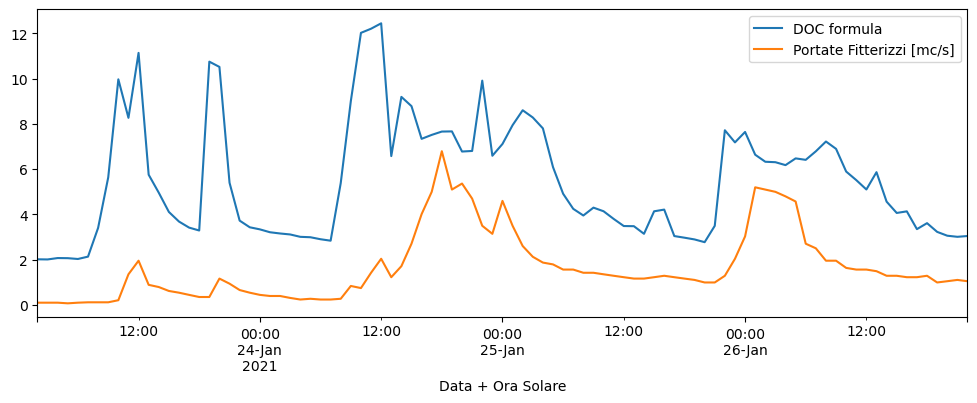

In [22]:
doc_flow = reduced_fitterizzi[['Data', 'Data + Ora Solare', 'DOC formula','Portate Fitterizzi [mc/s]']]
doc_flow.head()

first_year = doc_flow[(doc_flow['Data + Ora Solare'] > '2019-05-21 19:00:00') & (doc_flow['Data + Ora Solare'] < '2019-12-31 19:00:00')]
third_year = doc_flow[(doc_flow['Data + Ora Solare'] > '2021-01-15 01:00:00') & (doc_flow['Data + Ora Solare'] < '2021-12-31 19:00:00')]
third_year_first_month = doc_flow[(doc_flow['Data + Ora Solare'] > '2021-01-23 01:00:00') & (doc_flow['Data + Ora Solare'] < '2021-01-26 23:00:00')]

first_year.plot(x='Data + Ora Solare', y=['DOC formula', 'Portate Fitterizzi [mc/s]'], figsize=(12,4))
third_year.plot(x='Data + Ora Solare', y=['DOC formula', 'Portate Fitterizzi [mc/s]'], figsize=(12,4))
third_year_first_month.plot(x='Data + Ora Solare', y=['DOC formula', 'Portate Fitterizzi [mc/s]'], figsize=(12,4))

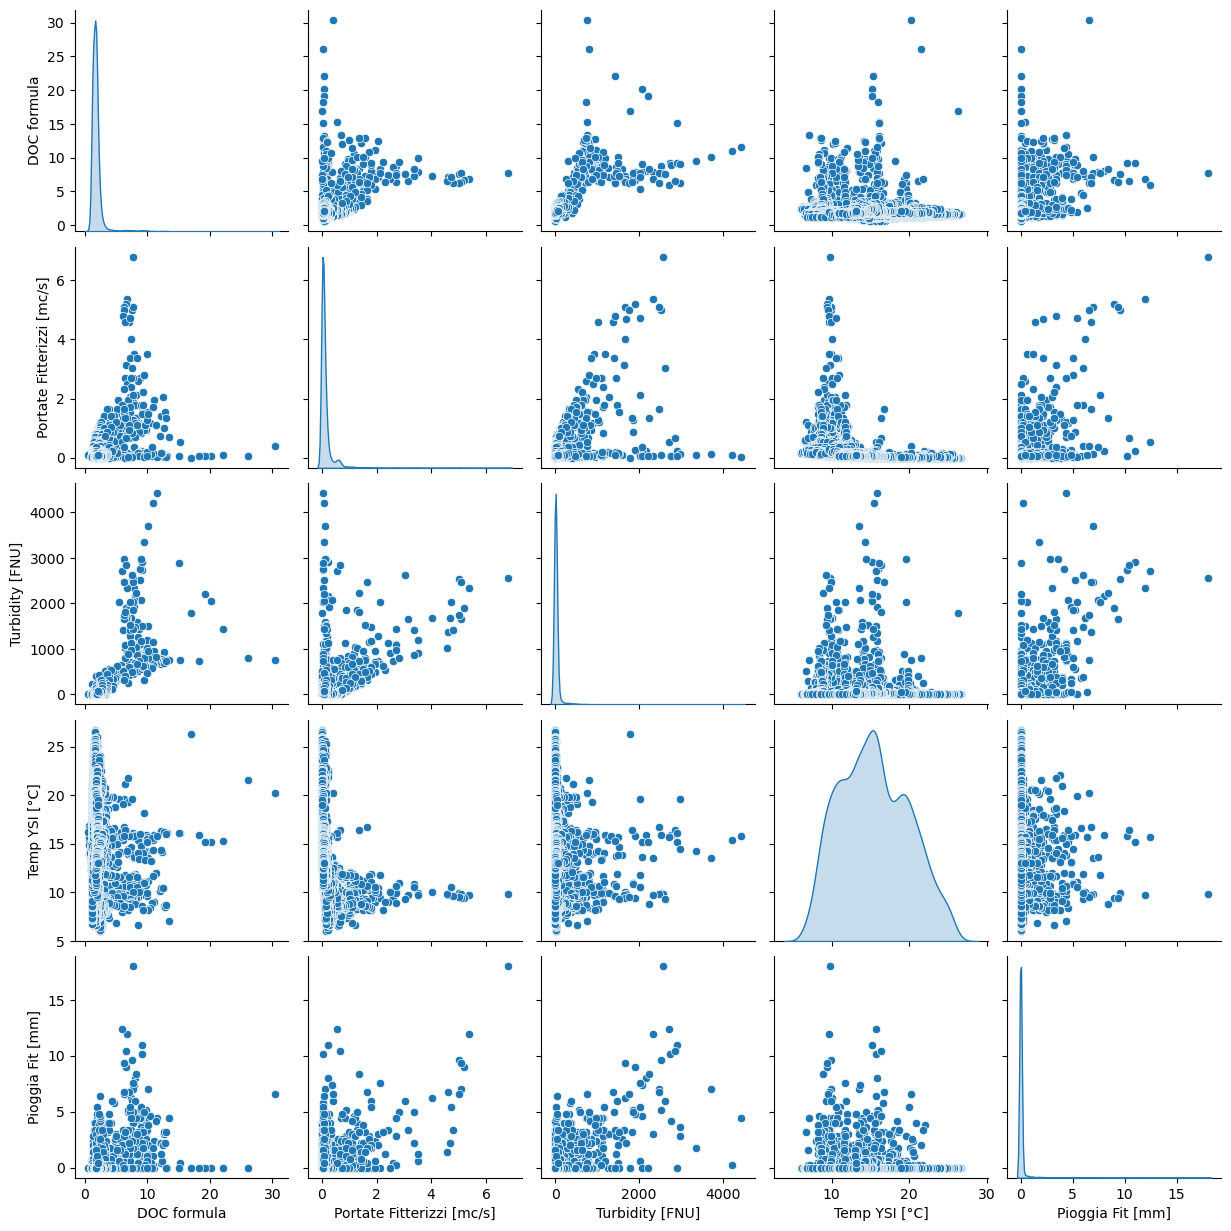

In [19]:
sns.pairplot(reduced_fitterizzi[[
    'DOC formula', 'Portate Fitterizzi [mc/s]', 'Turbidity [FNU]', 
    'Temp YSI [°C]', 'Pioggia Fit [mm]']], 
    diag_kind='kde')

## Clustering

In [23]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler 

<Axes: xlabel='Data', ylabel='Turbidity [FNU]'>

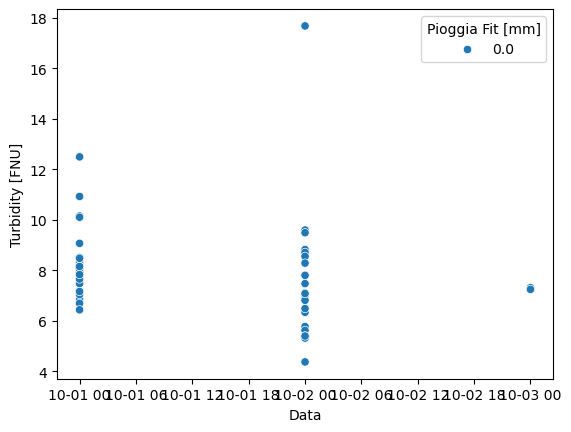

In [24]:
reduced_fitterizzi.head()
sns.scatterplot(data=reduced_fitterizzi.head(50), hue='Pioggia Fit [mm]', y='Turbidity [FNU]', x="Data")

In [25]:
#Scale each column in reduced_fitterizzi
scaler = StandardScaler()
drop_columns = ['Data', 'Ora Solare', 'Data + Ora Solare']
input_data = reduced_fitterizzi.drop(drop_columns, axis=1)
input_data = pd.DataFrame(scaler.fit_transform(input_data))
columns = [attr for attr in reduced_fitterizzi.columns if attr not in drop_columns]
input_data.columns = columns
input_data.head()

,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,fDOMcorrSoglia,fDOMcorr>soglia,DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit,DDOC
0,0.830166,-0.173671,0.550004,0.906075,-0.009615,0.906075,0.063741,0.063741,-0.379288,0.381922,-0.169771,-0.322187,0.925925,-0.349491,-0.680186,-0.513687,-0.007926
1,0.722851,-0.160324,0.470452,0.784886,-0.009636,0.784886,0.040571,0.040571,-0.390217,0.271734,-0.169771,-0.480815,1.059487,-0.312804,-0.680186,-0.736070,-0.032172
2,0.718017,-0.152852,0.389887,0.769127,-0.009635,0.769127,0.041862,0.041862,-0.379288,0.381922,-0.169771,-0.529624,1.148528,-0.349491,-0.680186,-0.513687,0.003613
3,0.775300,-0.164008,0.316976,0.817799,-0.009630,0.817799,0.046881,0.046881,-0.379288,0.381922,-0.169771,-0.517422,1.237570,-0.362331,-0.680186,-0.550751,0.009070
4,0.802612,-0.164238,0.250633,0.836614,-0.009626,0.836614,0.051908,0.051908,-0.379288,0.381922,-0.169771,-0.627242,1.282090,-0.380675,-0.680186,-0.550751,0.009080


In [26]:

X = input_data.to_numpy()

distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 17)
 
for k in K:
    # Building and fitting the model
    kmeanModel = KMeans(n_clusters=k, n_init="auto").fit(X)
    kmeanModel.fit(X)
 
    distortions.append(sum(np.min(cdist(input_data, kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / X.shape[0])
    inertias.append(kmeanModel.inertia_)
 
    mapping1[k] = sum(np.min(cdist(input_data, kmeanModel.cluster_centers_,
                                   'euclidean'), axis=1)) / X.shape[0]
    mapping2[k] = kmeanModel.inertia_

In [27]:
for key, val in mapping1.items():
    print(f'{key} : {val}')

1 : 3.3569646307047565
2 : 2.9758930284892458
3 : 2.8119858029172944
4 : 2.4764253103263756
5 : 2.4378959695944054
6 : 2.3490935260043466
7 : 2.3520030942166374
8 : 2.204032949380209
9 : 2.137739589507198
10 : 1.9817707182705049
11 : 1.9813621222838453
12 : 1.951822876138212
13 : 1.9357791747035593
14 : 1.8992243379713376
15 : 1.8846525478516245
16 : 1.8672875413835381


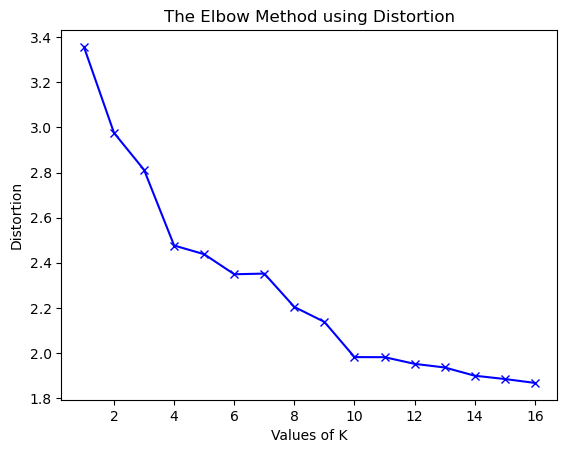

In [28]:
plt.plot(K, distortions, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

C:\Users\luisr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


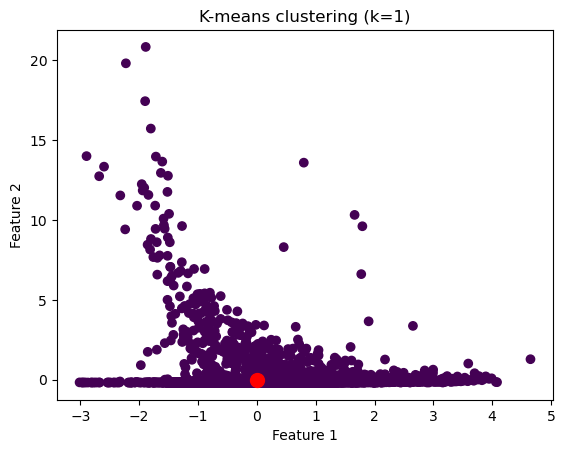

C:\Users\luisr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


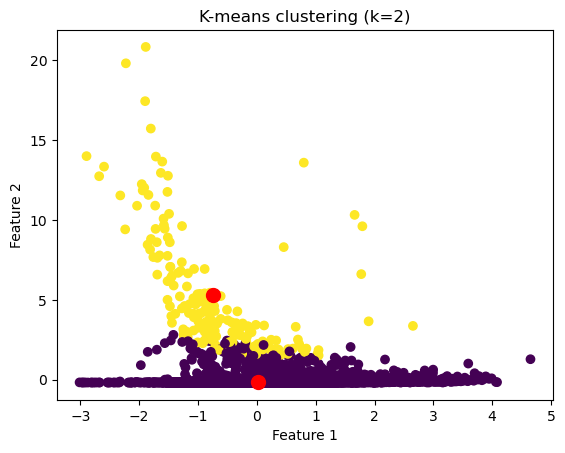

C:\Users\luisr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


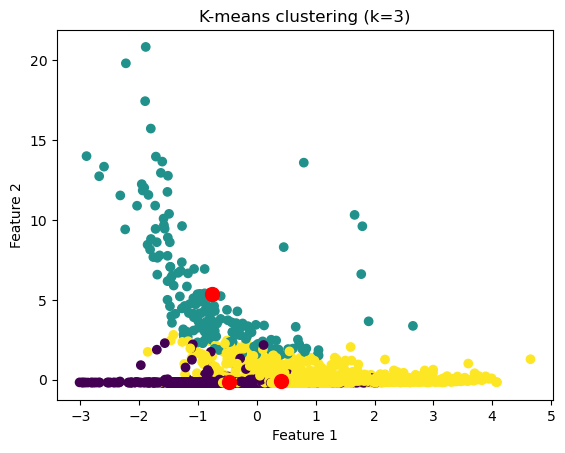

C:\Users\luisr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


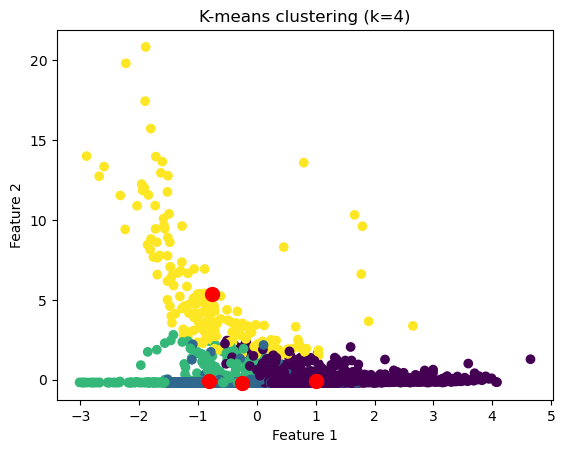

C:\Users\luisr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


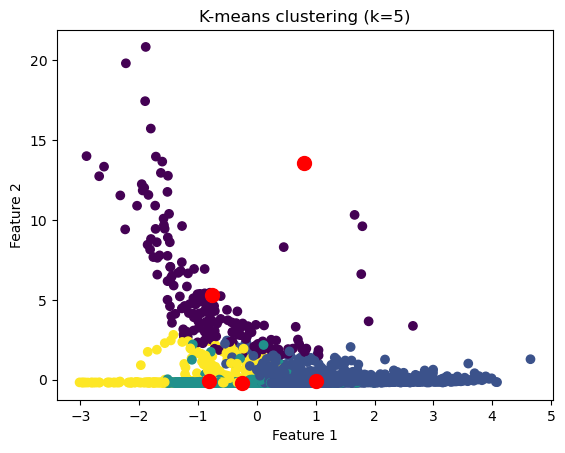

C:\Users\luisr\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


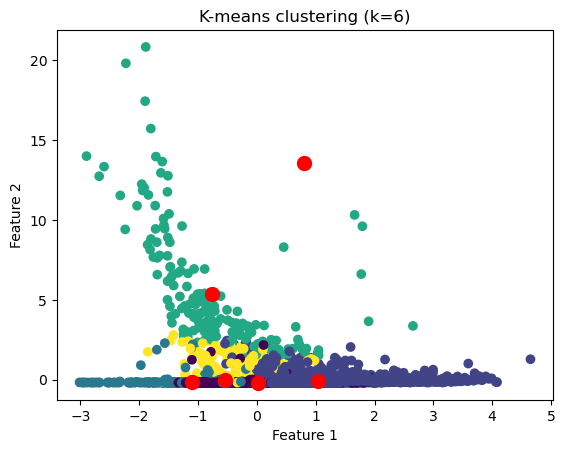

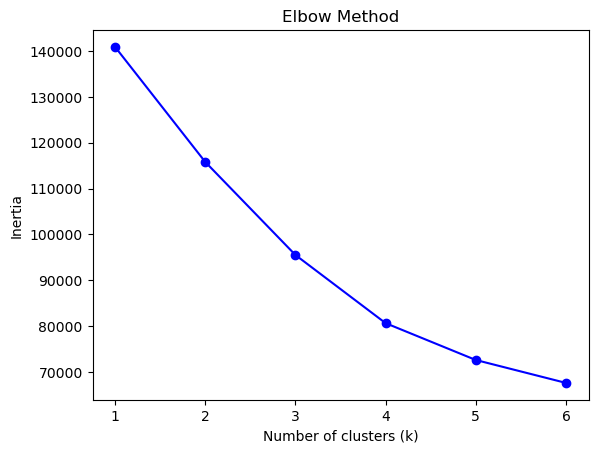

In [47]:
# Create a range of values for k
k_range = range(1, 7)
 
# Initialize an empty list to 
# store the inertia values for each k
inertia_values = []
 
# Fit and plot the data for each k value
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X)
    inertia_values.append(kmeans.inertia_)
    plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
    plt.scatter(kmeans.cluster_centers_[:, 0],\
                kmeans.cluster_centers_[:, 1], \
                s=100, c='red')
    plt.title('K-means clustering (k={})'.format(k))
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()
 
# Plot the inertia values for each k
plt.plot(k_range, inertia_values, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

# San Nicola


In [12]:
san_nicola = pd.read_excel('./Dati chimici_fisici.xlsx', header=0, sheet_name="San Nicola")

In [13]:
valid_columns = san_nicola.columns[:23]
valid_columns

Index(['Data', 'Ora Solare', 'Data + Ora Solare', 'fDOM Orario(QSU)',
       'Turbidity [FNU]', 'Temp YSI [°C]', 'fDOMT', 'fDOMcorr', 'DOC', 'Q_SN',
       'Livel Idro trasd [m]', 'Pioggia_Cav', 'Temp Cav [C°]',
       'Umidità Cav [%]', 'Rad Netta Cav  [W/mq]', 'Vel Vento Cav',
       'Pioggia_Fit', 'Temp Fitterizzi [C°]', 'Umidità Fitterizzi [%]',
       'Pres Atm Fitterizzi [hPa]', 'Rad Solare  Fitterizzi  [W/mq]',
       'Vel Vento  Fitterizzi', 'Livel Idro Fit [m]'],
      dtype='object')

In [14]:
reduced_san_nicola = san_nicola[valid_columns]
reduced_san_nicola.head()

,Data,Ora Solare,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,DOC,Q_SN,...,Umidità Cav [%],Rad Netta Cav [W/mq],Vel Vento Cav,Pioggia_Fit,Temp Fitterizzi [C°],Umidità Fitterizzi [%],Pres Atm Fitterizzi [hPa],Rad Solare Fitterizzi [W/mq],Vel Vento Fitterizzi,Livel Idro Fit [m]
0,2019-08-22,18:00:00,2019-08-22 18:00:00,29.350000,0.0,23.099667,28.802654,28.802654,2.355343,0.001964,...,48.0,-,2.4,0.0,29,46,995.5,38,-,0.28
1,2019-08-22,19:00:00,2019-08-22 19:00:00,31.080000,0.0,22.546500,30.335713,30.335713,2.438129,0.002491,...,42.0,-,2.4,0.0,24.9,62,996,0,-,0.28
2,2019-08-22,20:00:00,2019-08-22 20:00:00,32.065000,0.0,21.509500,30.983520,30.983520,2.473110,0.002491,...,43.0,-,1.9,0.0,22.4,68,996.7,0,-,0.29
3,2019-08-22,21:00:00,2019-08-22 21:00:00,32.665000,0.0,20.924500,31.385869,31.385869,2.494837,0.003134,...,50.0,-,0.8,0.0,21.5,70,996.8,0,-,0.29
4,2019-08-22,22:00:00,2019-08-22 22:00:00,32.821667,0.0,20.530333,31.417413,31.417413,2.496540,0.003134,...,44.0,-,1.5,0.0,21,69,996.8,0,-,0.30


In [15]:
reduced_san_nicola.describe()

,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],fDOMT,fDOMcorr,DOC,Q_SN,Temp Cav [C°],Umidità Cav [%],Vel Vento Cav,Pioggia_Fit,Livel Idro Fit [m]
count,11732.000000,12127.000000,12217.000000,11733.000000,11733.000000,11735.000000,12195.000000,11733.000000,11733.000000,11733.000000,11733.000000,12217.000000
mean,25.325967,34.315403,14.452531,23.127395,36.265995,2.758186,0.038006,17.489844,64.829228,2.101879,0.153254,0.294495
std,10.539438,151.950934,4.460712,10.006566,258.038564,13.932902,0.086885,6.981334,16.454606,2.031511,0.891352,0.100328
min,-4.405000,0.000000,4.626167,-3.875889,-173.993874,-8.595669,0.000025,-0.800000,12.000000,0.000000,0.000000,0.050000
25%,17.151667,0.723021,10.782000,15.238807,16.441574,1.687639,0.004443,11.900000,54.000000,0.500000,0.000000,0.230000
50%,25.871667,2.328333,14.013833,23.339511,24.879438,2.143427,0.012243,16.900000,66.000000,1.500000,0.000000,0.280000
75%,32.036250,6.867500,18.282500,29.537089,31.423709,2.496876,0.032844,22.900000,76.000000,3.200000,0.000000,0.340000
max,90.103333,2683.228333,27.777841,79.007057,18848.264143,1018.606264,1.866843,36.800000,101.000000,13.700000,35.000000,1.650000


In [16]:
reduced_san_nicola.isna().sum()

Data                              488
Ora Solare                        488
Data + Ora Solare                 488
fDOM Orario(QSU)                  488
Turbidity [FNU]                    93
Temp YSI [°C]                       3
fDOMT                             487
fDOMcorr                          487
DOC                               485
Q_SN                               25
Livel Idro trasd [m]              488
Pioggia_Cav                       487
Temp Cav [C°]                     487
Umidità Cav [%]                   487
Rad Netta Cav  [W/mq]             488
Vel Vento Cav                     487
Pioggia_Fit                       487
Temp Fitterizzi [C°]              487
Umidità Fitterizzi [%]            487
Pres Atm Fitterizzi [hPa]         487
Rad Solare  Fitterizzi  [W/mq]    487
Vel Vento  Fitterizzi             488
Livel Idro Fit [m]                  3
dtype: int64

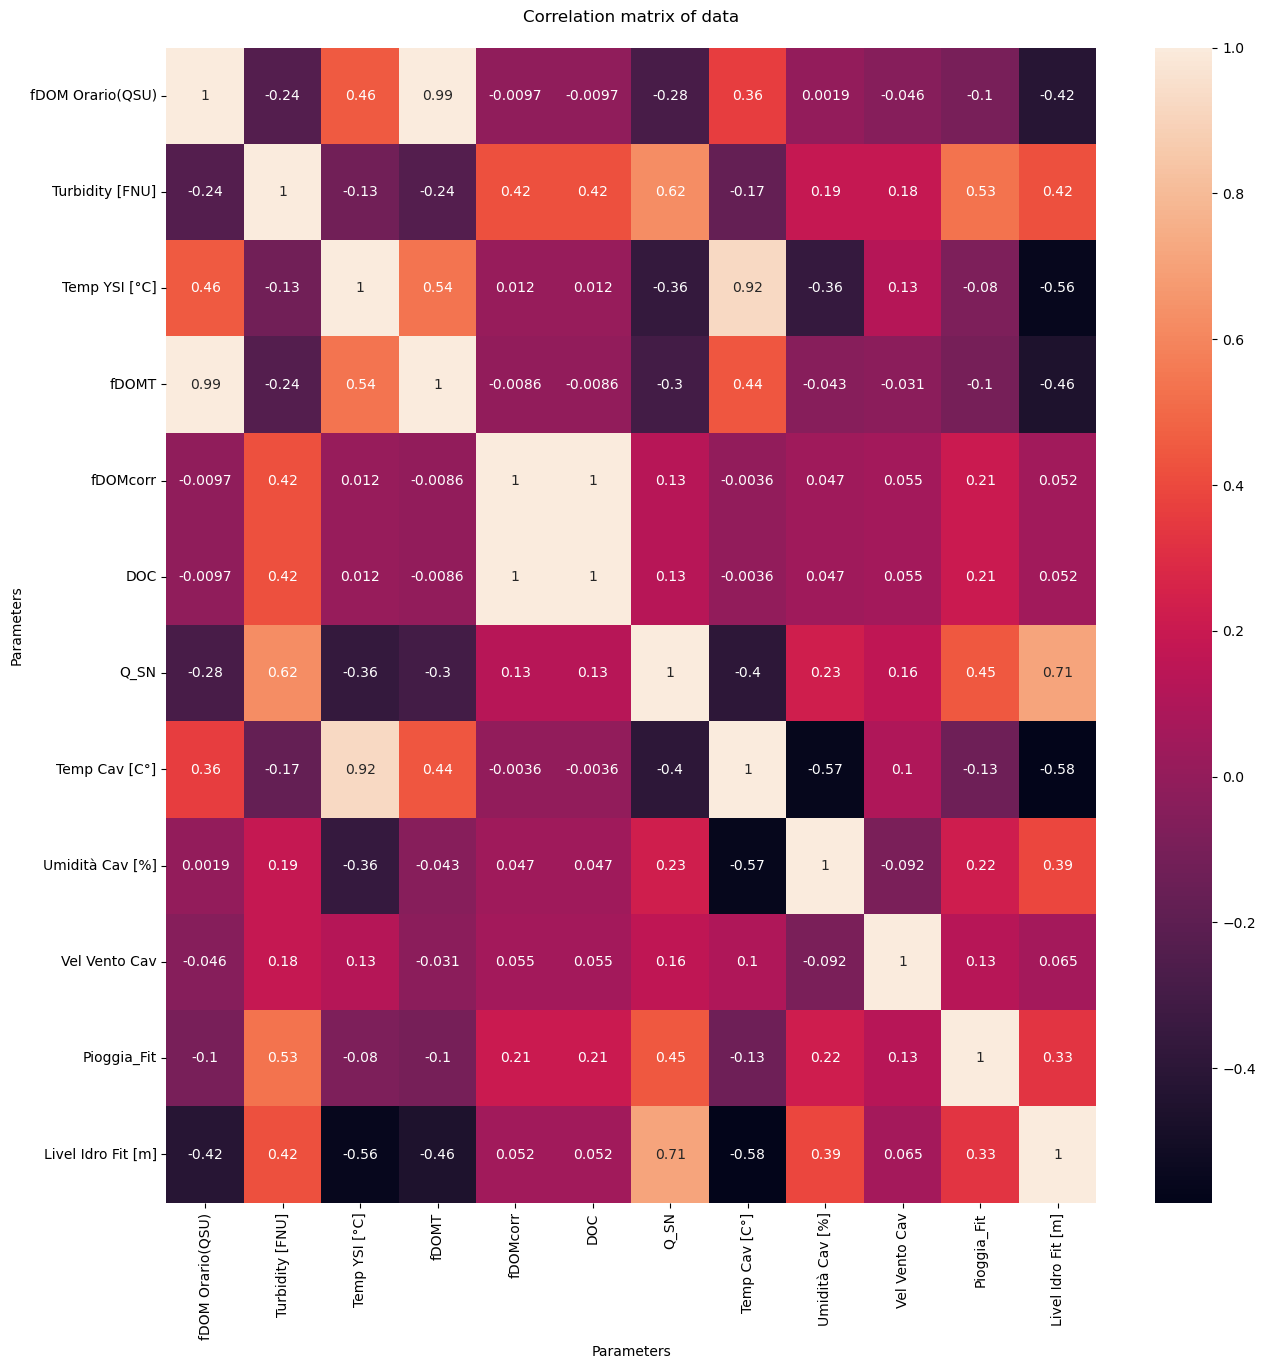

In [17]:
plt.figure(figsize = (15,15))
hm = sns.heatmap(reduced_san_nicola.corr(numeric_only=True), annot=True)
hm.set(xlabel='Parameters', ylabel='Parameters', title = "Correlation matrix of data\n")
plt.show()

<Axes: xlabel='Data + Ora Solare'>

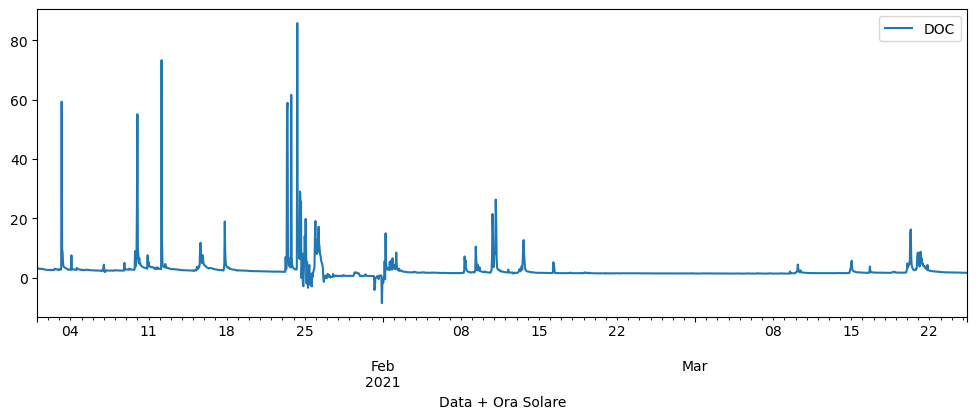

In [18]:
doc_flow = reduced_san_nicola[['Data', 'Data + Ora Solare', 'DOC', 'Q_SN']]
doc_flow.head()

third_year_first_quarter = doc_flow[(doc_flow['Data + Ora Solare'] > '2021-01-01 00:00:00') & (doc_flow['Data + Ora Solare'] < '2021-03-30 23:00:00')]
third_year_first_quarter.plot(x='Data + Ora Solare', y=['DOC'], figsize=(12,4))

# Turbidity

In [29]:
turbidity = pd.read_excel('./Dati chimici_fisici.xlsx', header=0, sheet_name="Torbidità SN Fitterizzi")

In [30]:
turbidity.columns

Index(['Data + Ora Solare', 'Turbidity [FNU] F', 'Turbidity [FNU] SN',
       'Portate F [mc/s]', 'Portate SN [mc/s]', 'Unnamed: 5'],
      dtype='object')

In [31]:
turbidity = turbidity[turbidity.columns[:-1]]
turbidity.head()

,Data + Ora Solare,Turbidity [FNU] F,Turbidity [FNU] SN,Portate F [mc/s],Portate SN [mc/s]
0,2021-01-16 13:00:00,47.281667,29.938333,0.240741,0.085110
1,2021-01-16 14:00:00,43.475000,25.341667,0.309828,0.075154
2,2021-01-16 15:00:00,40.030000,23.260000,0.273587,0.057976
3,2021-01-16 16:00:00,41.918333,18.968333,0.211053,0.066131
4,2021-01-16 17:00:00,50.010000,18.746667,0.240741,0.066131


In [32]:
turbidity.describe()

,Data + Ora Solare,Turbidity [FNU] F,Turbidity [FNU] SN,Portate F [mc/s],Portate SN [mc/s]
count,1630,1630.000000,1630.000000,1630.000000,1630.000000
mean,2021-02-19 11:29:59.999999744,117.991431,103.332455,0.520163,0.143044
min,2021-01-16 13:00:00,2.261667,3.260000,0.062436,0.017151
25%,2021-02-02 12:15:00,6.736250,7.363750,0.184301,0.050628
50%,2021-02-19 11:30:00,17.831667,14.169167,0.349708,0.096065
75%,2021-03-08 10:45:00,66.882500,54.830417,0.618112,0.169795
max,2021-03-25 10:00:00,2616.018333,2683.228333,6.795935,1.866843
std,NaN,292.496119,255.958931,0.600310,0.164608


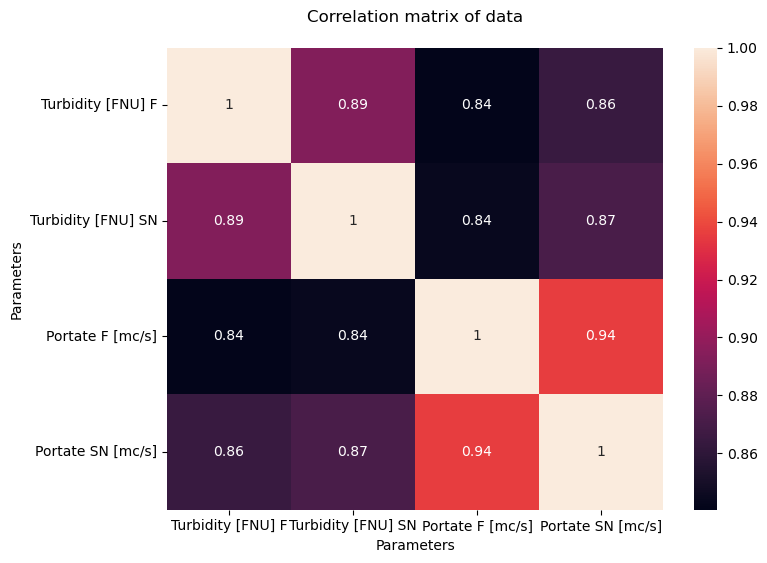

In [33]:
plt.figure(figsize = (8,6))
hm = sns.heatmap(turbidity.corr(numeric_only=True), annot=True)
hm.set(xlabel='Parameters', ylabel='Parameters', title = "Correlation matrix of data\n")
plt.show()

<Axes: xlabel='Data + Ora Solare'>

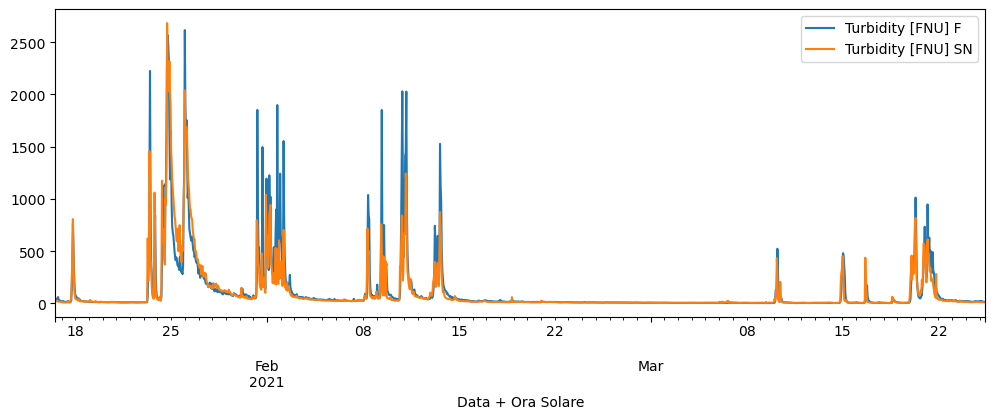

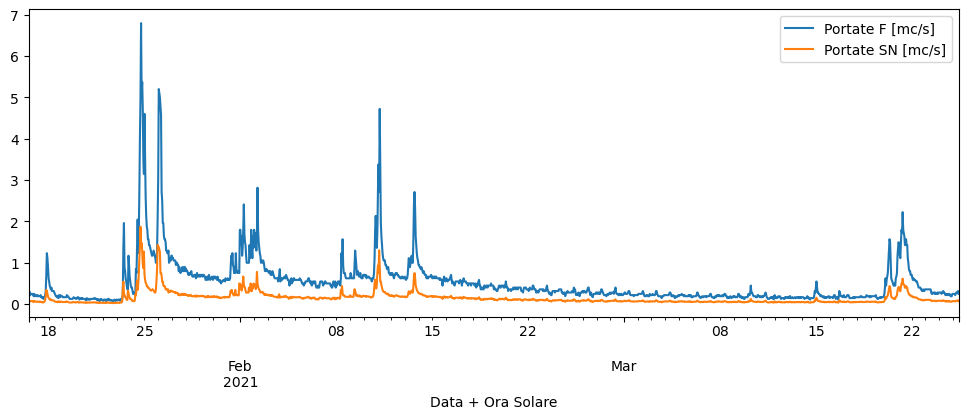

In [34]:
third_year_first_quarter = turbidity[(turbidity['Data + Ora Solare'] > '2021-01-01 00:00:00') & (turbidity['Data + Ora Solare'] < '2021-03-30 23:00:00')]
third_year_first_quarter.plot(x='Data + Ora Solare', y=['Turbidity [FNU] F', 'Turbidity [FNU] SN'], figsize=(12,4))
third_year_first_quarter.plot(x='Data + Ora Solare', y=['Portate F [mc/s]', 'Portate SN [mc/s]'], figsize=(12,4))

## Scatter Plot

<Axes: xlabel='Turbidity [FNU] F', ylabel='Turbidity [FNU] SN'>

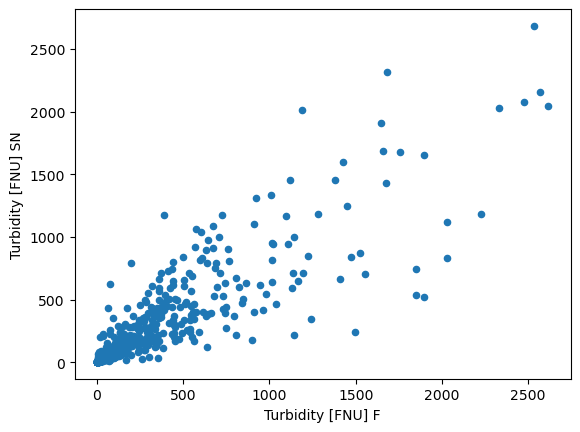

In [35]:
turbidity.plot.scatter("Turbidity [FNU] F", "Turbidity [FNU] SN", s=None, c=None)

## Regression

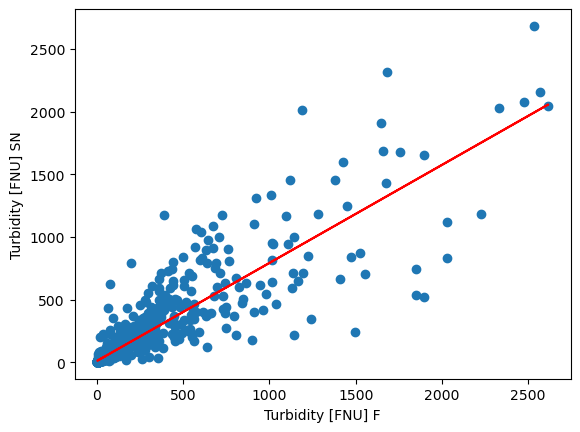

In [36]:
X = turbidity.iloc[:, 1].values.reshape(-1, 1)  # iloc[:, 1] is the column of X => Turbidity [FNU] F
Y = turbidity.iloc[:, 2].values.reshape(-1, 1)  # df.iloc[:, 4] is the column of Y => Turbidity [FNU] SN
linear_regressor = linear_model.LinearRegression()
linear_regressor.fit(X, Y)
Y_pred = linear_regressor.predict(X)

plt.scatter(X, Y)
plt.xlabel("Turbidity [FNU] F")
plt.ylabel("Turbidity [FNU] SN")
plt.plot(X, Y_pred, color='red')
plt.show()

In [37]:
print(linear_regressor.intercept_, linear_regressor.coef_, linear_regressor.score(X, Y_pred))

[11.08294048] [[0.78183232]] 1.0


## Meteo

In [38]:
meteo = pd.read_excel('./Dati chimici_fisici.xlsx', header=0, sheet_name="Meteo_TUTTI_giornalieri")
meteo.describe()

,Data,Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Rad Solare Fit [W/mq]
count,810,811.000000,811.000000,732.000000,811.000000
mean,2020-09-05 16:01:19.999999744,2.716893,18.019458,68.662028,205.777190
min,2019-05-23 01:00:00,0.000000,0.000000,0.000000,0.000000
25%,2019-12-11 07:00:00,0.000000,12.445833,59.375000,123.395833
50%,2020-09-26 13:00:00,0.000000,18.212500,67.416667,215.375000
75%,2021-04-23 19:00:00,0.500000,23.741667,79.531250,296.916667
max,2021-11-25 01:00:00,87.400000,33.020833,99.000000,369.666667
std,NaN,8.007376,6.594862,14.331788,100.561889


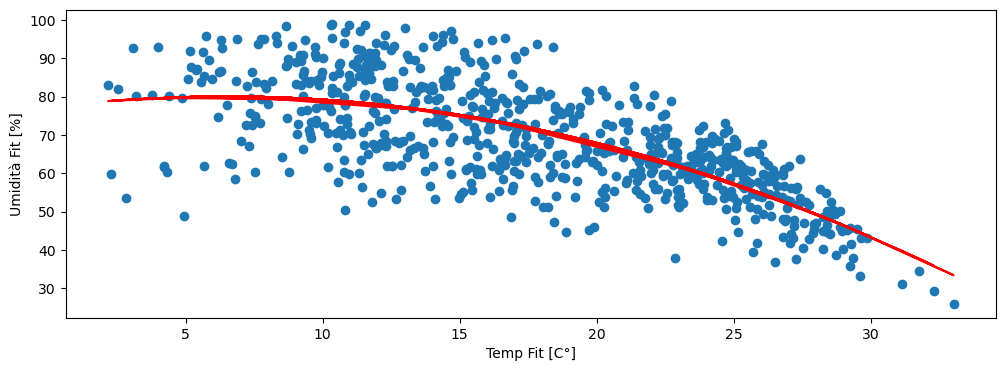

In [39]:
from sklearn.preprocessing import PolynomialFeatures

clean_meteo = meteo.dropna().copy()

X = clean_meteo.iloc[:, 2].values.reshape(-1, 1)  # iloc[:, 1] is the column of X => Temp Fit [C°]
Y = clean_meteo.iloc[:, 3].values.reshape(-1, 1)  # df.iloc[:, 4] is the column of Y => Umidità Fit [%]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X.reshape(-1, 1))

poly_reg_model = linear_model.LinearRegression()
poly_reg_model.fit(poly_features, Y)
Y_pred = poly_reg_model.predict(poly_features)

plt.figure(figsize=(12,4))
plt.xlabel("Temp Fit [C°]")
plt.ylabel("Umidità Fit [%]")
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.show()

In [40]:
print(poly_reg_model.intercept_, poly_reg_model.coef_, poly_reg_model.score(poly_features, Y))

[77.26602937] [[ 0.85461636 -0.06611897]] 0.5177173219313209
